# Step 1 Formulate Research Question 

How do advertising budget accross TV, Radio, and Newspaper influence the product sales?

## Variables 
- Independent Variables
    - TV
    - Radio
    - Newspaper
- Dependent Variable
    - Sales

# Step 2 Data Cleaning 

In [36]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

print("all installed")

all installed


In [21]:
df = pd.read_csv("advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [22]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [24]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [25]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

# Step 3 Exploratory Data Analysis 

A. Scatter Plot (each features vs Sales)

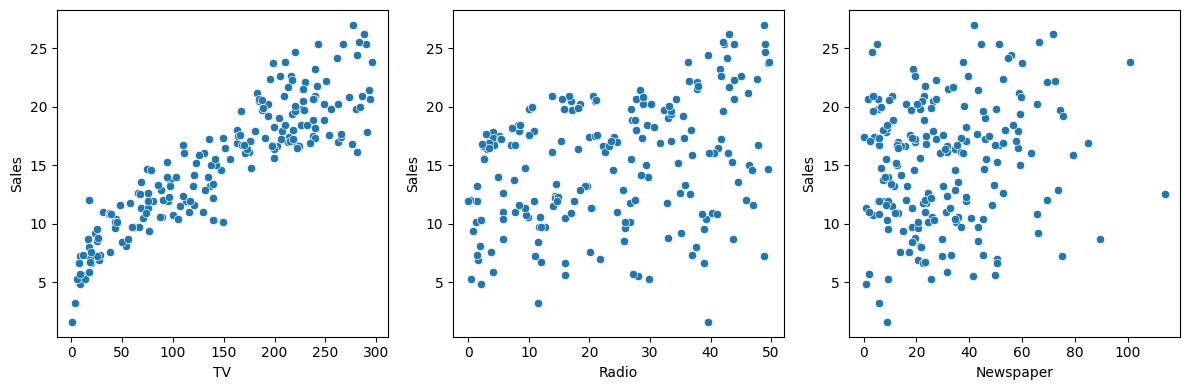

In [27]:
plt.figure(figsize=(12,4))

plt.subplot(1, 3, 1)
sns.scatterplot(x="TV", y="Sales", data=df)
plt.xlabel("TV")
plt.ylabel("Sales")

plt.subplot(1, 3, 2)
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.xlabel("Radio")
plt.ylabel("Sales")

plt.subplot(1, 3, 3)
sns.scatterplot(x="Newspaper", y="Sales", data=df)  
plt.xlabel("Newspaper")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

B. Correlation Matrix 

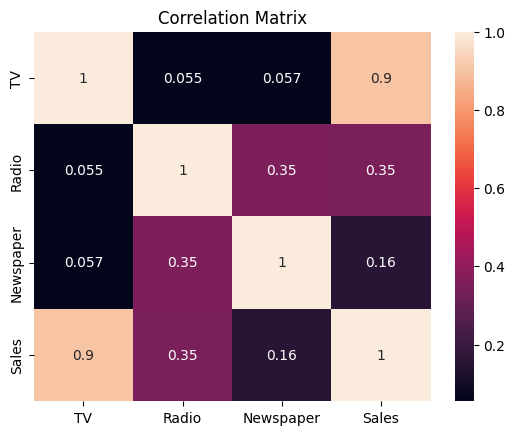

In [28]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

C. Pairplot

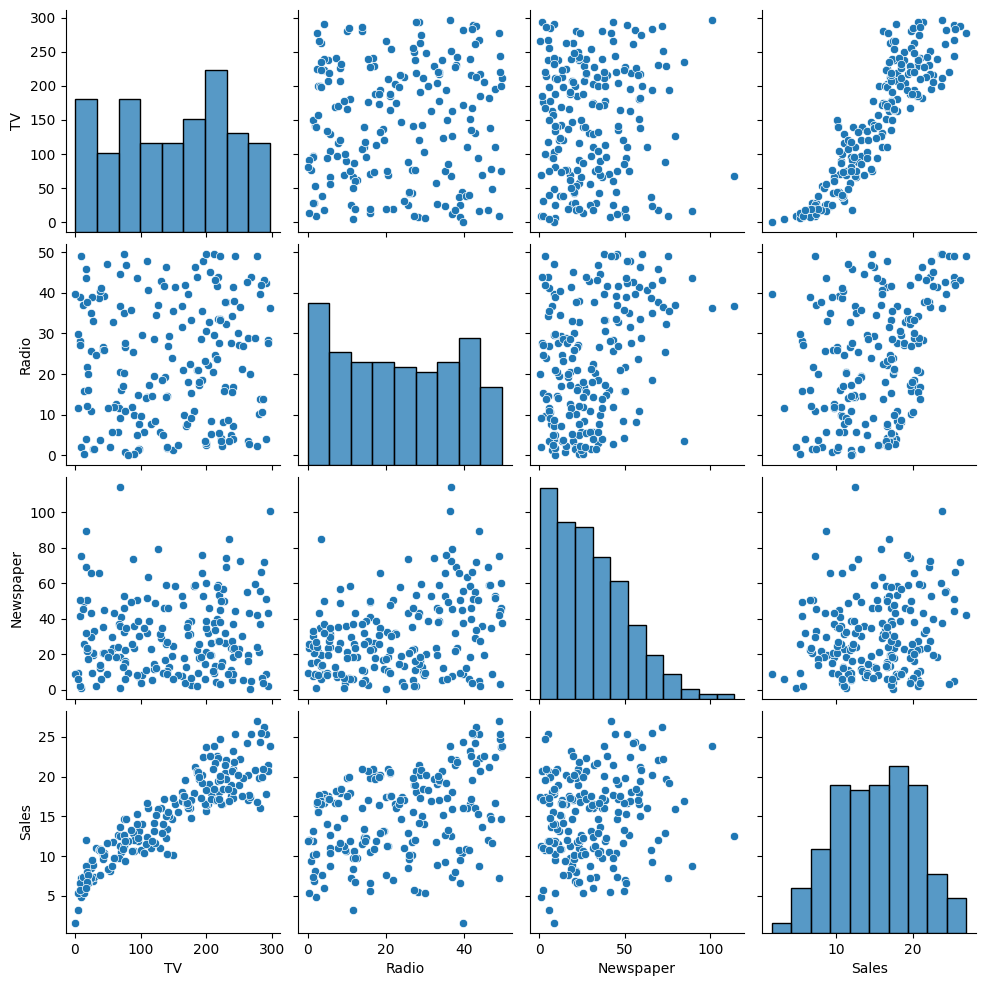

In [29]:
sns.pairplot(df)
plt.show()

# Step 4 Model Training

In [30]:
x = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})
coefficients

Intercept: 4.714126402214127


,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


In [34]:
y_pred = model.predict(x_test)
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head()

,Actual,Predicted
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719


# Step 5 Performance Evaluation

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Sqaured Error:", mse)
print("Root Mean Squared Error", rmse)
print("R-squared:", r2)

Mean Absolute Error: 1.2748262109549338
Mean Sqaured Error: 2.9077569102710896
Root Mean Squared Error 1.7052146229349223
R-squared: 0.9059011844150826


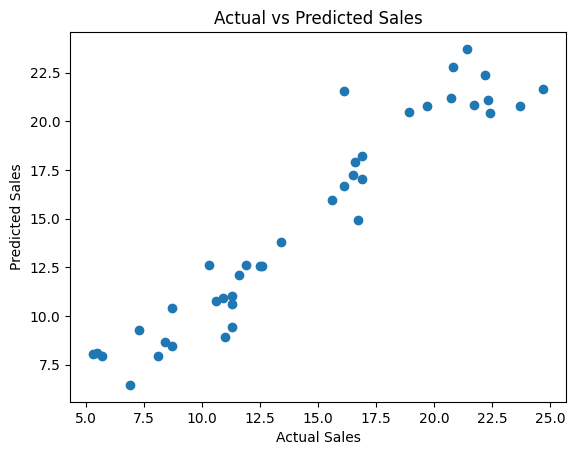

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

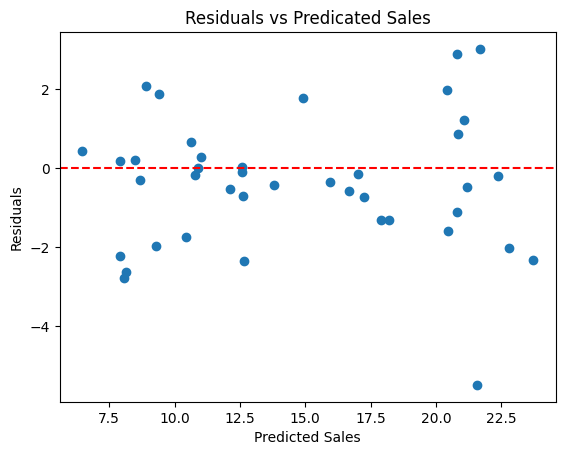

In [43]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicated Sales")
plt.show()

In [45]:
new_data = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})
prediction = model.predict(new_data)
print("Predicted Sales for new data:", prediction[0])

Predicted Sales for new data: 16.00561083602645


In [46]:
%pip install pandas scikit-learn

import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

if "model" not in globals():
    # If the trained model is not already available in this session, train it first.
    if "df" not in globals():
        df = pd.read_csv("advertising.csv")
        df.columns = ["TV", "Radio", "Newspaper", "Sales"]
    X = df[["TV", "Radio", "Newspaper"]]
    y = df["Sales"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

export_path = "advertising_model.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

Note: you may need to restart the kernel to use updated packages.
Trained model exported to advertising_model.pkl



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
